In [2]:
import pandas as pd
df = pd.read_csv('pbp_all.txt')
print(df.shape)
df.head()

(2638698, 29)


,season,gameId,gameDate,matchup,homeTeamId,homeAbbreviation,awayTeamId,awayAbbreviation,homeWin,description,...,actionType,line,homeFouls,awayFouls,homeBonus,awayBonus,homeFreeThrows,awayFreeThrows,homeEjections,awayEjections
0,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,Period Start,...,period,1.5,0,0,0,0,0,0,0,0
1,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,Jump Ball B. Lopez vs. N. Claxton: Tip to G. A...,...,jumpball,1.5,0,0,0,0,0,0,0,0
2,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,MISS G. Allen 26' 3PT,...,3pt,1.5,0,0,0,0,0,0,0,0
3,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,K. Durant REBOUND (Off:0 Def:1),...,rebound,1.5,0,0,0,0,0,0,0,0
4,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,G. Antetokounmpo shooting personal FOUL (1 PF)...,...,foul,1.5,1,0,0,0,0,2,0,0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

df = pd.read_csv('pbp_all.txt')


df['scoreTimePressure'] = np.tanh(
    df['scoreDif'].to_numpy(dtype=np.float64) / 
    (df['secondsLeft'].to_numpy(dtype=np.float64) + 1.0)
)


numeric_features = [
    'periodSecondsLeft', 'secondsLeft', 'scoreDif', 'scoreTimePressure',
    'pointsTotal', 'possession', 'homeFouls', 'awayFouls',
    'homeBonus', 'awayBonus', 'homeFreeThrows', 'awayFreeThrows',
    'homeEjections', 'awayEjections', 'line'
]
one_hot_features = ['quarter']
target = 'homeWin'


train_df = df[df['season'].isin(['2021-22', '2022-23', '2023-24'])].copy()
val_df = df[df['season'] == '2024-25'].copy()
test_df = df[df['season'] == '2025-26'].copy()


all_cols = numeric_features + one_hot_features + [target]
train_df = train_df.dropna(subset=all_cols)
val_df = val_df.dropna(subset=all_cols)
test_df = test_df.dropna(subset=all_cols)


feature_cols = numeric_features + one_hot_features
preprocess = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_features),
])

feature_pipeline = Pipeline([('preprocess', preprocess)])
feature_pipeline.fit(train_df[feature_cols])

X_train = feature_pipeline.transform(train_df[feature_cols])
X_val = feature_pipeline.transform(val_df[feature_cols])
X_test = feature_pipeline.transform(test_df[feature_cols])

y_train = train_df[target].values
y_val = val_df[target].values
y_test = test_df[target].values

print(f'Train: {X_train.shape}')
print(f'Val: {X_val.shape}')
print(f'Test: {X_test.shape}')

Train: (1546485, 20)
Val: (522221, 20)
Test: (521897, 20)


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import brier_score_loss

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_val_pred_xgb = xgb_model.predict_proba(X_val)[:, 1]
brier_xgb = brier_score_loss(y_val, y_val_pred_xgb)
print(f'XGBoost Brier Score (Val): {brier_xgb:.4f}')

XGBoost Brier Score (Val): 0.1510


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_val_pred_rf = rf_model.predict_proba(X_val)[:, 1]
brier_rf = brier_score_loss(y_val, y_val_pred_rf)
print(f'Random Forest Brier Score (Val): {brier_rf:.4f}')

Random Forest Brier Score (Val): 0.1500


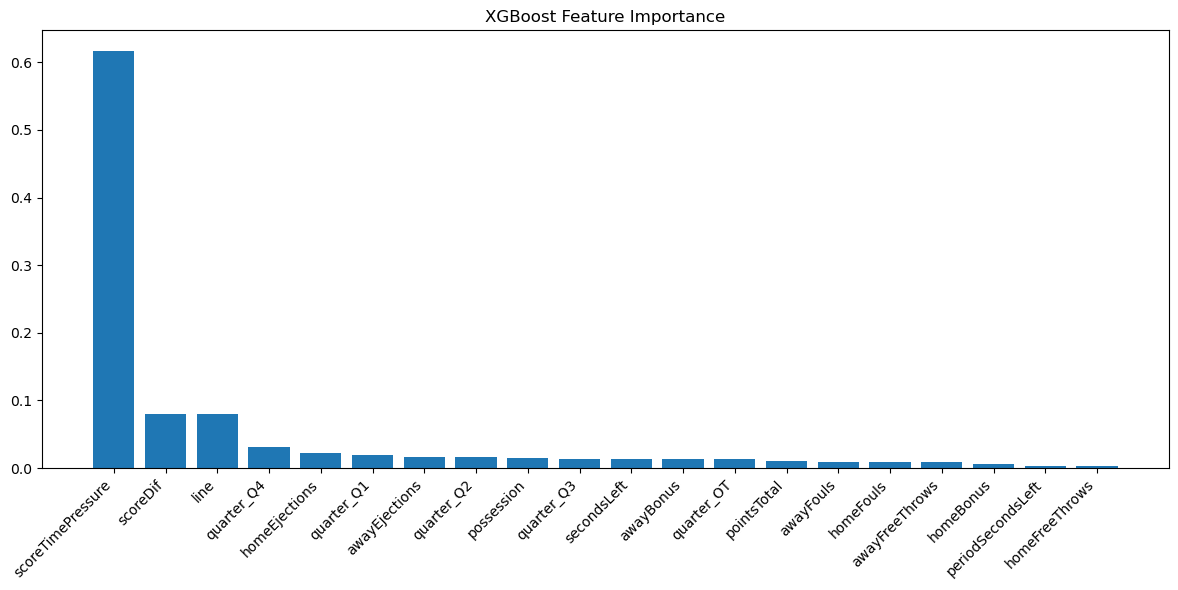

In [14]:
import matplotlib.pyplot as plt

# 获取特征名字
feature_names = numeric_features + list(
    feature_pipeline.named_steps['preprocess']
    .named_transformers_['oh']
    .get_feature_names_out(['quarter'])
)

# XGBoost feature importance
importances = xgb_model.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

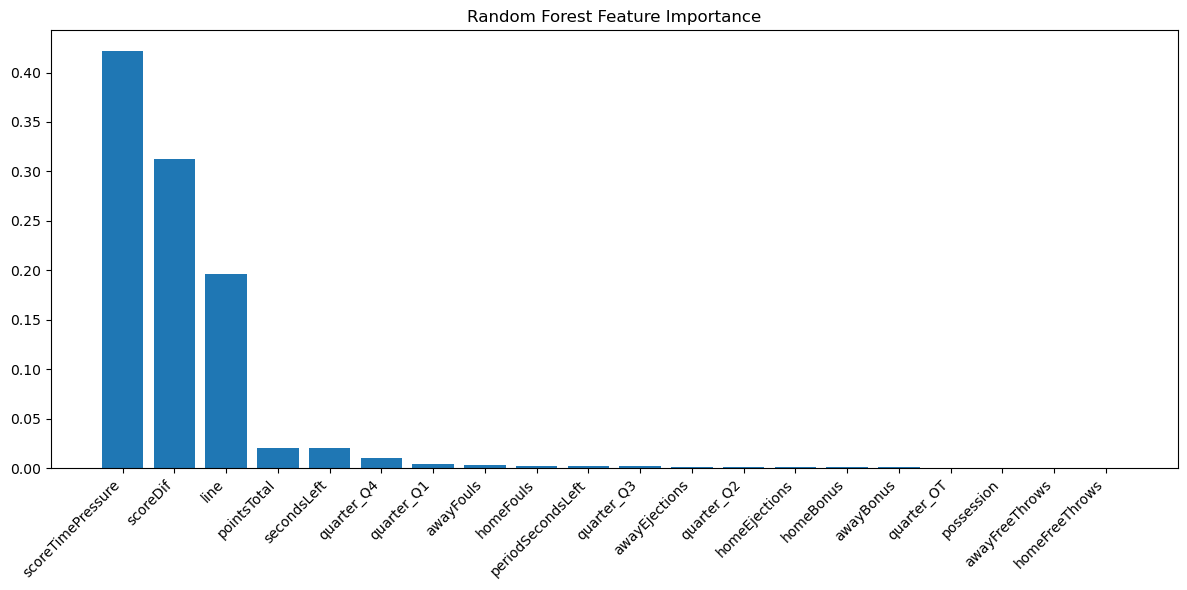

In [15]:
# Random Forest feature importance
importances_rf = rf_model.feature_importances_
indices_rf = importances_rf.argsort()[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(len(importances_rf)), importances_rf[indices_rf])
plt.xticks(range(len(importances_rf)), [feature_names[i] for i in indices_rf], rotation=45, ha='right')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()